In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/Si_ML_ready_clean.csv")

print(df.columns)
print(len(df))

Index(['Synthesizable', 'Material ID', 'Formula', 'Crystal System',
       'Space Group Symbol', 'Space Group Number', 'Sites',
       'Energy Above Hull', 'Formation Energy', 'Predicted Stable', 'Volume',
       'Density', 'Band Gap', 'Is Gap Direct', 'Is Metal', 'Magnetic Ordering',
       'Total Magnetization', 'Bulk Modulus, Voigt', 'Bulk Modulus, Reuss',
       'Bulk Modulus, VRH', 'Shear Modulus, Voigt', 'Shear Modulus, Reuss',
       'Shear Modulus, VRH', 'Elastic Anisotropy', 'Weighted Surface Energy',
       'Surface Anisotropy', 'Shape Factor', 'Work Function',
       'Piezoelectric Modulus', 'Total Dielectric Constant',
       'Ionic Dielectric Constant', 'Static Dielectric Constant', 'Si_frac',
       'O_frac', 'C_frac', 'N_frac'],
      dtype='object')
438


DATA ACQUISITION

In [15]:
from mp_api.client import MPRester
import pandas as pd

API_KEY = "lFHsBvSH3VD2ETcdiID1R435rj4VgPAg"

with MPRester(API_KEY) as mpr:
    docs = mpr.materials.summary.search(
        elements=["Ti", "O"],
        num_elements=2,
        fields=["material_id", "band_gap", "structure", "formula_pretty"]
    )

data = []

for d in docs:
    data.append({
        "material_id": str(d.material_id),
        "formula": d.formula_pretty,
        "band_gap": d.band_gap,
        "structure": d.structure.as_dict()  # 🔥 FIX HERE
    })

df = pd.DataFrame(data)

print("Rows:", len(df))
df.head()

Retrieving SummaryDoc documents:   0%|          | 0/124 [00:00<?, ?it/s]

Rows: 124


,material_id,formula,band_gap,structure
0,mp-1244926,TiO,0.0069,"{'@module': 'pymatgen.core.structure', '@class..."
1,mp-1244944,TiO,0.0000,"{'@module': 'pymatgen.core.structure', '@class..."
2,mp-1245098,TiO2,2.6007,"{'@module': 'pymatgen.core.structure', '@class..."
3,mp-1245134,TiO2,2.4383,"{'@module': 'pymatgen.core.structure', '@class..."
4,mp-1245141,TiO,0.0163,"{'@module': 'pymatgen.core.structure', '@class..."


In [16]:
df.to_json("../data/raw/TiO2_structures.json", orient="records")

In [17]:
from pymatgen.core import Composition

def get_fractions(formula):
    comp = Composition(formula)
    total = comp.num_atoms
    return pd.Series({
        "Ti_frac": comp["Ti"] / total if "Ti" in comp else 0,
        "O_frac": comp["O"] / total if "O" in comp else 0
    })

df[["Ti_frac", "O_frac"]] = df["formula"].apply(get_fractions)

In [18]:
df_tio2 = df[
    (abs(df["Ti_frac"] - 1/3) < 0.01) &
    (abs(df["O_frac"] - 2/3) < 0.01)
]

print("TiO2 count:", len(df_tio2))
df_tio2.head()

TiO2 count: 46


,material_id,formula,band_gap,structure,Ti_frac,O_frac
2,mp-1245098,TiO2,2.6007,"{'@module': 'pymatgen.core.structure', '@class...",0.333333,0.666667
3,mp-1245134,TiO2,2.4383,"{'@module': 'pymatgen.core.structure', '@class...",0.333333,0.666667
6,mp-1245308,TiO2,2.3002,"{'@module': 'pymatgen.core.structure', '@class...",0.333333,0.666667
7,mp-1245321,TiO2,2.4087,"{'@module': 'pymatgen.core.structure', '@class...",0.333333,0.666667
9,mp-777129,TiO2,3.3487,"{'@module': 'pymatgen.core.structure', '@class...",0.333333,0.666667


In [19]:
from pymatgen.core import Structure

def load_structure(struct_dict):
    return Structure.from_dict(struct_dict)

In [22]:
import numpy as np
from pymatgen.analysis.local_env import CrystalNN

def compute_ti_features(structure):

    cnn = CrystalNN()

    ti_o_distances = []
    ti_o_ti_angles = []

    for i, site in enumerate(structure):
        if site.species_string != "Ti":
            continue

        neighbors = cnn.get_nn_info(structure, i)

        o_neighbors = [
            n for n in neighbors if n["site"].species_string == "O"
        ]

        # Ti–O distances
        for n in o_neighbors:
            dist = structure.get_distance(i, n["site_index"])
            ti_o_distances.append(dist)

        # Ti–O–Ti angles
        for n1 in o_neighbors:
            o_index = n1["site_index"]

            o_neighbors_2 = cnn.get_nn_info(structure, o_index)

            ti_neighbors = [
                n for n in o_neighbors_2 if n["site"].species_string == "Ti"
            ]

            for n2 in ti_neighbors:
                ti_index_2 = n2["site_index"]

                if ti_index_2 == i:
                    continue

                angle = structure.get_angle(i, o_index, ti_index_2)
                ti_o_ti_angles.append(angle)

    # Handle empty cases
    if len(ti_o_distances) == 0 or len(ti_o_ti_angles) == 0:
        return None

    return {
        "avg_ti_o_distance": np.mean(ti_o_distances),
        "avg_ti_o_ti_angle": np.mean(ti_o_ti_angles),
        "min_ti_o_ti_angle": np.min(ti_o_ti_angles),
        "max_ti_o_ti_angle": np.max(ti_o_ti_angles),
        "std_ti_o_ti_angle": np.std(ti_o_ti_angles)
    }

In [23]:
features = []

for _, row in df_tio2.iterrows():
    structure = load_structure(row["structure"])

    feat = compute_ti_features(structure)

    if feat is None:
        continue

    feat["band_gap"] = row["band_gap"]
    features.append(feat)

df_features = pd.DataFrame(features)

print("Final dataset size:", len(df_features))
df_features.head()

/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/pymatgen/analysis/local_env.py:4021: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r1 = _get_radius(structure[n])
/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/pymatgen/analysis/local_env.py:4023: UserWarning: No oxidation states specified on sites! For better results, set the site oxidation states in the structure.
  r2 = _get_radius(entry["site"])
/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/pymatgen/analysis/local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


Final dataset size: 42


,avg_ti_o_distance,avg_ti_o_ti_angle,min_ti_o_ti_angle,max_ti_o_ti_angle,std_ti_o_ti_angle,band_gap
0,1.947544,91.637919,10.338471,168.039886,39.563319,2.6007
1,1.982719,90.197290,5.635844,160.264453,39.650663,2.4383
2,1.976344,89.406571,3.094319,169.735390,36.777035,2.3002
3,1.965827,92.358026,14.441429,155.398413,36.424358,2.4087
4,1.826492,105.598086,13.216614,161.381522,54.333995,3.3487


Model Training

In [24]:
X = df_features.drop(columns=["band_gap"])
y = df_features["band_gap"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

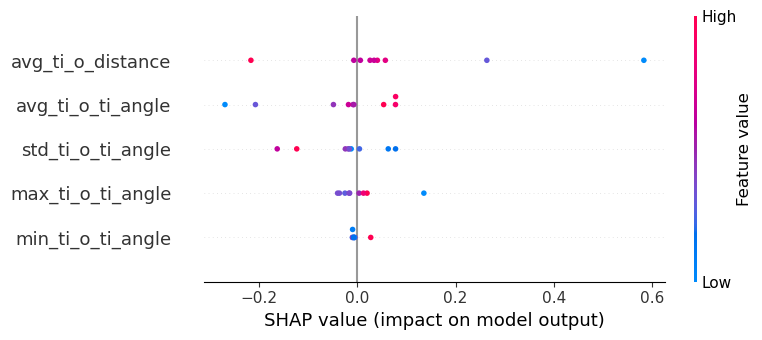

In [34]:
import shap

explainer = shap.Explainer(model, X_train)

shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [32]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.4099198888888899
R2: 0.3566482235662416


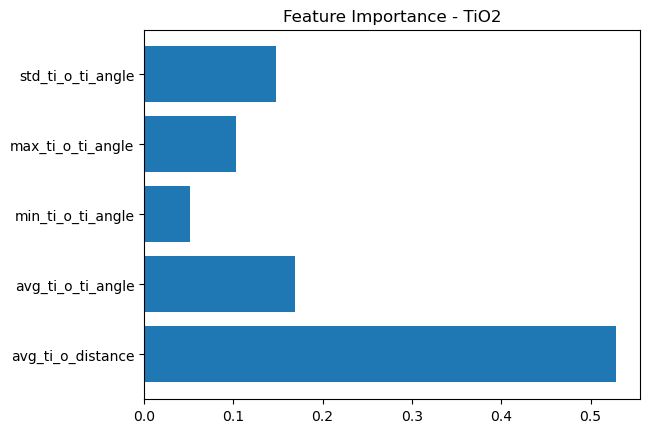

In [35]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance - TiO2")
plt.show()

In [36]:
import joblib
joblib.dump(model, "../models/TiO2_model.pkl")

['../models/TiO2_model.pkl']